In [ ]:
!pip install sentence-transformers seaborn matplotlib

In [ ]:
sentences = [
    # Cricket (4 sentences)
    "The batsman scored a century in the final match",
    "The bowler delivered a perfect yorker to take a wicket",
    "The team celebrated their victory after winning the series",
    "Fielders worked together to stop the boundary",

    # Cooking (3 sentences)
    "She prepared a delicious pasta with fresh ingredients",
    "Baking a cake requires precise measurements and timing",
    "The chef added spices to enhance the flavor of the dish",

    # Cybersecurity (3 sentences)
    "Strong passwords help protect against cyber attacks",
    "Encryption ensures that sensitive data remains secure",
    "Firewalls prevent unauthorized access to computer networks"
]

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

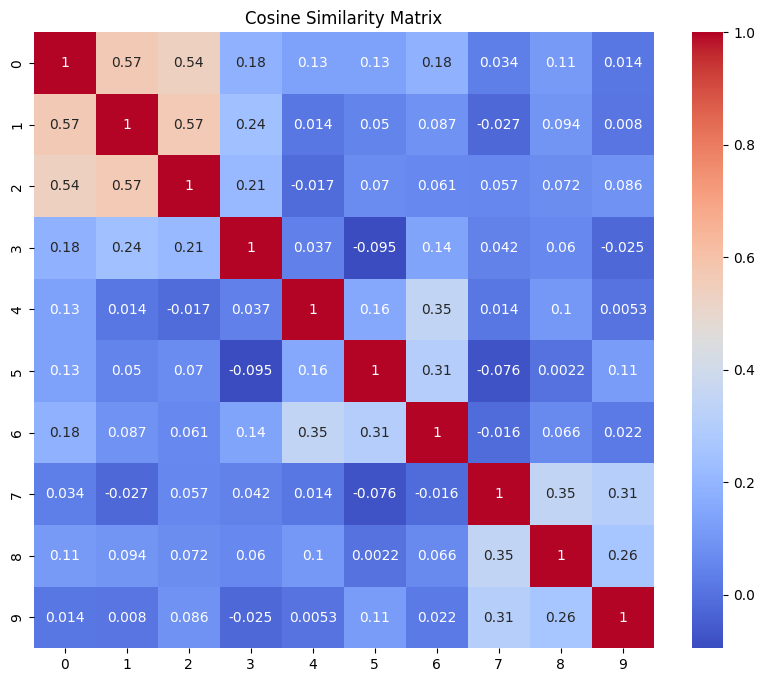

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 similar sentences
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The batsman scored a century in the final match
Similarity Score: 1.0000

Sentence: The bowler delivered a perfect yorker to take a wicket
Similarity Score: 0.5682

